# Entrena tu primera red neuronal para clasificación de imágenes desde 0


Hoy vamos a construir, paso a paso, un clasificador de imágenes que distingue entre **piedra 🪨, papel 📄 y tijeras ✂️**. Lo haremos 3 veces, cada vez con un modelo más poderoso:

| # | Modelo | Idea clave |
|---|--------|-----------|
| 1 | **MLP** (perceptrón multicapa) | La red neuronal más simple posible |
| 2 | **CNN LeNet-5** | Redes que "ven" patrones espaciales (1998, Yann LeCun) |
| 3 | **Transfer learning (ResNet-18)** | Reutilizar una red ya entrenada con millones de imágenes |

### El pipeline que repetiremos siempre

En *deep learning*, entrenar **cualquier** modelo sigue las mismas etapas. Memoriza este flujo, porque lo usarás toda tu carrera:

```
Datos →  Preprocesamiento →  DataLoader →  Modelo → Loss → Optimizer → Entrenar → Evaluar
```

> 💡 **Stack:** PyTorch · torchvision · timm · NumPy · scikit-learn · matplotlib


## Setup: librerías, semilla y dispositivo

Antes de empezar, tres cosas:

1. **Importar** las librerías que usaremos.
2. **Fijar una semilla** (*seed*): las redes neuronales usan números aleatorios (pesos iniciales, orden de los datos...). Fijar la semilla hace que todos obtengamos resultados parecidos.
3. **Elegir el dispositivo**: si tienes GPU (NVIDIA → `cuda`, Mac → `mps`) el entrenamiento será mucho más rápido. Si no, usamos la CPU.


In [1]:
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from PIL import Image

# Semilla para que los resultados sean reproducibles
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


if torch.backends.mps.is_available():      # GPU de Apple (Mac M1/M2/M3...)
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():            # GPU NVIDIA
    DEVICE = torch.device("cuda")
else:                                      # CPU
    DEVICE = torch.device("cpu")

print(f"PyTorch {torch.__version__} | Entrenaremos en: {DEVICE}")

PyTorch 2.14.0+cu130 | Entrenaremos en: cuda


In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("Versión CUDA de PyTorch:", torch.version.cuda)
print("GPUs detectadas:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.14.0+cu130
CUDA disponible: True
Versión CUDA de PyTorch: 13.0
GPUs detectadas: 1
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [29]:
import sys
import torch

print("Python del notebook:")
print(sys.executable)

print("\nTorch:")
print(torch.__file__)
print(torch.__version__)


Python del notebook:
c:\Users\SAHUA\Documents\datascience-g8\01-python-intro\.venv\Scripts\python.exe

Torch:
c:\Users\SAHUA\Documents\datascience-g8\01-python-intro\.venv\Lib\site-packages\torch\__init__.py
2.14.0+cpu


In [ ]:
#from google.colab import drive

#drive.mount('/content/drive')

## Conoce tus datos

**Regla de oro:** antes de entrenar nada, *mira* tus datos. ¿Cuántas imágenes hay? ¿Las clases están balanceadas? ¿Cómo se ven?

Nuestro dataset está organizado en carpetas, una por clase:

```
data/rock-paper-scissors/
├── rock/      ← imágenes de piedra
├── paper/     ← imágenes de papel
└── scissors/  ← imágenes de tijeras
```

Esta estructura de "una carpeta por clase" es un estándar, y PyTorch la entiende directamente.


In [2]:
DATA_DIR = Path(r"C:\Users\SAHUA\Documents\datascience-g8\01-python-intro\data\SmallRPSDataset-master")

for carpeta in sorted(DATA_DIR.iterdir()):
    if carpeta.is_dir():
        n_imagenes = len(list(carpeta.glob("*.png")))
        print(f"{carpeta.name:>10s} → {n_imagenes} imágenes")


     paper → 299 imágenes
      rock → 299 imágenes
  scissors → 299 imágenes


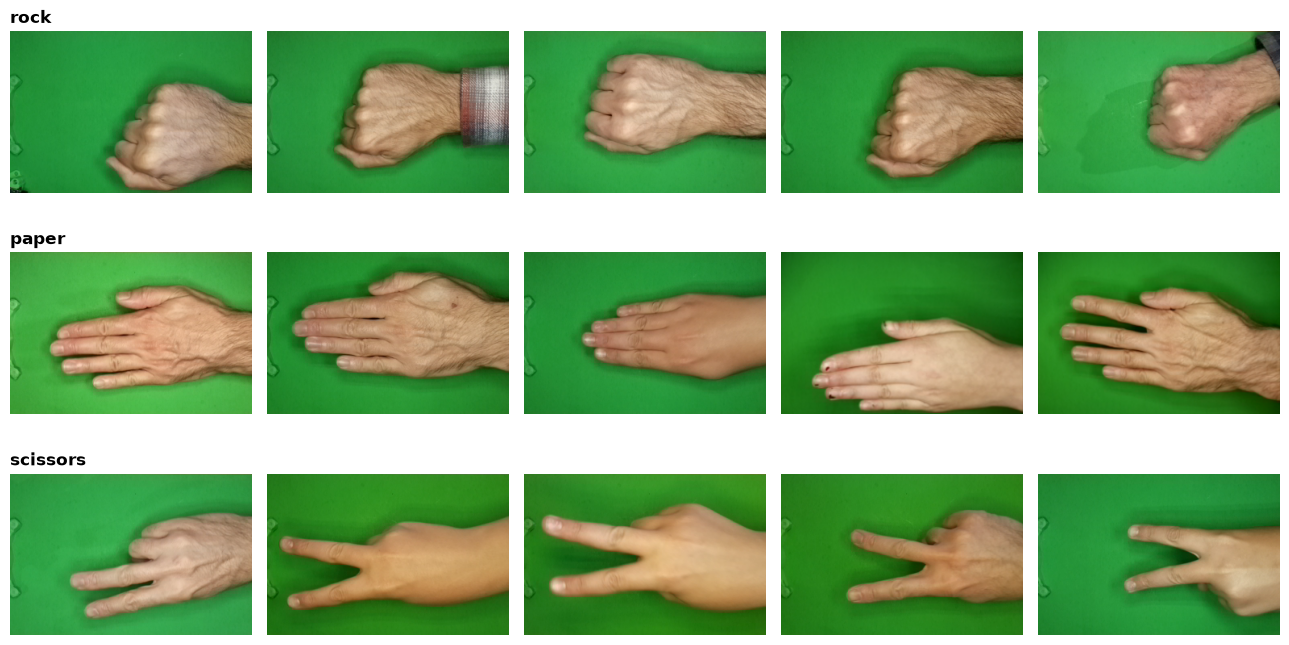

In [3]:
# Veamos 5 ejemplos de cada clase
clases_carpetas = ["rock", "paper", "scissors"]

fig, axes = plt.subplots(3, 5, figsize=(13, 7))
for fila, clase in enumerate(clases_carpetas):
    rutas = sorted((DATA_DIR / clase).glob("*.png"))[:5]
    for col, ruta in enumerate(rutas):
        axes[fila, col].imshow(Image.open(ruta))
        axes[fila, col].axis("off")
        if col == 0:
            axes[fila, col].set_title(clase, loc="left", fontweight="bold")
plt.tight_layout()
plt.show()


### ¿Qué "ve" la computadora?

Para nosotros esto son manos; para la computadora, cada imagen es una **tabla de números**:

- Cada imagen mide **300 × 200 píxeles**.
- Cada píxel tiene **3 números** (Rojo, Verde, Azul), entre 0 y 255.
- Total: 300 × 200 × 3 = **180,000 números por imagen**.

Una red neuronal es una máquina que recibe esos números y aprende a transformarlos en una respuesta: *"esto es papel"*.


## Preprocesamiento: preparar las imágenes

Las imágenes crudas no entran directo al modelo. Les aplicamos **transformaciones**:

| Transformación | ¿Para qué? |
|----------------|-----------|
| `Resize(64×64)` | Reducir el tamaño → menos números → entrenamiento más rápido |
| `ToTensor()` | Convertir la imagen a un *tensor* de PyTorch, con valores entre 0 y 1 |
| `Normalize(...)` | Centrar los valores alrededor de 0 → la red aprende más fácil |

> 💡 **¿Por qué normalizar?** Las redes neuronales aprenden mejor cuando los números de entrada son pequeños y están centrados en 0 (aprox. entre -1 y 1) en lugar de ir de 0 a 255.


In [4]:
IMG_SIZE_MLP = 32

transform_mlp = transforms.Compose([
    transforms.Resize((IMG_SIZE_MLP, IMG_SIZE_MLP)),
    transforms.ToTensor(),                       # imagen → tensor con valores [0, 1]
    transforms.Normalize(mean=[0.5, 0.5, 0.5],   # [0, 1] → [-1, 1]
                         std=[0.5, 0.5, 0.5]),
])

print(transform_mlp)


Compose(
    Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)


## Dataset y DataLoader: servir los datos al modelo

Dos piezas clave de PyTorch:

- **`Dataset`** → sabe *dónde* están los datos y cómo leer uno. Usamos `ImageFolder`, que asigna la etiqueta según la carpeta (rock=1... ¡lo decide alfabéticamente!).
- **`DataLoader`** → entrega los datos en **batches** (grupos, p. ej. de 64) y los **mezcla** (*shuffle*) en cada época.

### ¿Por qué dividir los datos?

| Split | % | ¿Para qué? |
|-------|---|-----------|
| **Train** | 70% | El modelo aprende con estas imágenes |
| **Validation** | 15% | Vigilamos el aprendizaje durante el entrenamiento |
| **Test** | 15% | Examen final: imágenes que el modelo **jamás vio** |

> Es como estudiar para un examen: practicas con unos ejercicios (train), te autoevalúas con otros (val), y el profesor te toma el examen con preguntas nuevas (test).


In [5]:
BATCH_SIZE = 64

def crear_dataloaders(transform, batch_size=BATCH_SIZE):
    """Crea los DataLoaders de train/val/test con un transform dado.

    Usamos siempre la misma semilla, así los 3 modelos se evalúan
    exactamente con las mismas imágenes de test (comparación justa).
    """
    dataset = datasets.ImageFolder(DATA_DIR, transform=transform)

    n_total = len(dataset)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    n_test = n_total - n_train - n_val

    generador = torch.Generator().manual_seed(SEED)
    train_ds, val_ds, test_ds = random_split(
        dataset, [n_train, n_val, n_test], generator=generador
    )

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size)
    test_dl = DataLoader(test_ds, batch_size=batch_size)
    return train_dl, val_dl, test_dl, dataset.classes


train_dl_mlp, val_dl_mlp, test_dl_mlp, CLASES = crear_dataloaders(transform_mlp)

print(f"Clases (orden alfabético): {CLASES}")
print(f"Train: {len(train_dl_mlp.dataset)} | Val: {len(val_dl_mlp.dataset)} | Test: {len(test_dl_mlp.dataset)}")


Clases (orden alfabético): ['paper', 'rock', 'scissors']
Train: 627 | Val: 134 | Test: 136


Forma del batch de imágenes: torch.Size([64, 3, 32, 32])  ← [batch, canales, alto, ancho]
Forma del batch de etiquetas: torch.Size([64])
Primeras etiquetas: [0, 2, 2, 2, 2, 2, 2, 0]


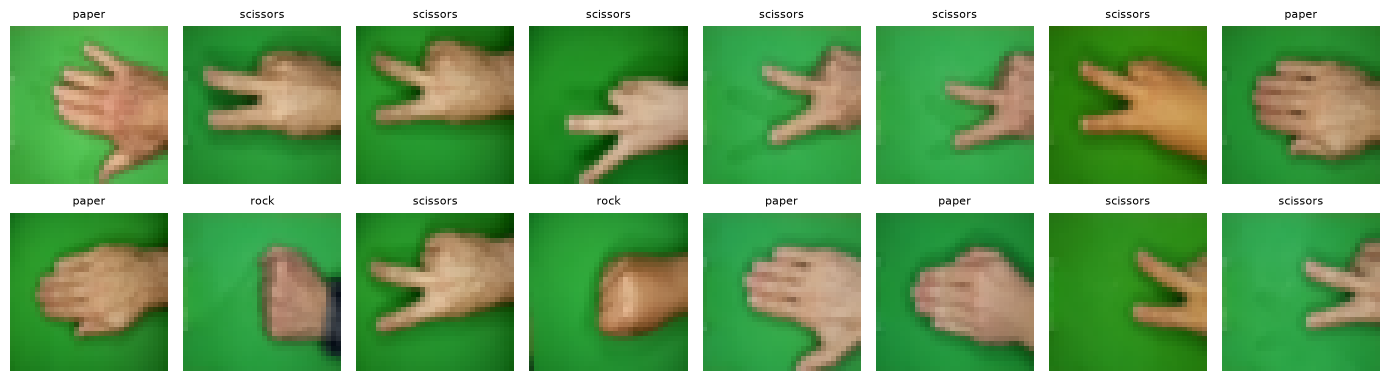

In [7]:
# Saquemos UN batch para ver qué recibe el modelo
imagenes, etiquetas = next(iter(train_dl_mlp))

print(f"Forma del batch de imágenes: {imagenes.shape}  ← [batch, canales, alto, ancho]")
print(f"Forma del batch de etiquetas: {etiquetas.shape}")
print(f"Primeras etiquetas: {etiquetas[:8].tolist()}")

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax, img, etiqueta in zip(axes.flat, imagenes, etiquetas):
    img = img * 0.5 + 0.5                  # deshacemos la normalización para visualizar
    ax.imshow(img.permute(1, 2, 0))        # [canales, alto, ancho] → [alto, ancho, canales]
    ax.set_title(CLASES[etiqueta], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()


## Modelo 1: MLP (perceptrón multicapa)

Nuestra primera red neuronal. Un MLP solo entiende **listas planas de números**, así que:

1. **`Flatten`**: aplana la imagen de 3×64×64 a una lista de **12,288 números**.
2. **Capas `Linear`**: cada neurona combina todos los números de entrada con sus propios "pesos" (los pesos son lo que la red *aprende*).
3. **`ReLU`**: una función simple (si es negativo → 0) que le permite a la red aprender relaciones no lineales.
4. **Capa de salida**: 3 números, uno por clase. El más alto = la predicción.

```
imagen 3×32×32 → Flatten → 3,072 → [512 neuronas] → [128 neuronas] → [3 salidas]
```

⚠️ **Problema del MLP:** al aplanar, la imagen pierde su estructura espacial — la red no sabe qué píxeles eran vecinos. Es como leer un libro con todas las letras en orden aleatorio.


In [8]:
class MLP(nn.Module):
    def __init__(self, num_clases=3):
        super().__init__()
        self.red = nn.Sequential(
            nn.Flatten(),                            # 3×32×32 → 3,072
            nn.Linear(3 * 32 * 32, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_clases),              # 3 salidas: una por clase
        )

    def forward(self, x):
        return self.red(x)


def contar_parametros(modelo):
    return sum(p.numel() for p in modelo.parameters() if p.requires_grad)


modelo_mlp = MLP().to(DEVICE)
print(modelo_mlp)
print(f"\nParámetros entrenables: {contar_parametros(modelo_mlp):,}")


MLP(
  (red): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=3, bias=True)
  )
)

Parámetros entrenables: 1,639,427


## Loss y Optimizer: ¿cómo aprende una red?

Una red empieza con pesos **aleatorios** (predice cualquier cosa). Aprender = ajustar esos pesos. Para eso necesitamos dos piezas:

- **Loss (función de pérdida)** — mide *qué tan equivocada* está la red. Si predice "tijeras" y era "piedra", la loss es alta. Usamos `CrossEntropyLoss`, la estándar para clasificación.
- **Optimizer (optimizador)** — decide *cómo corregir* los pesos para que la loss baje, usando los gradientes (la dirección de mejora). Usamos `Adam`, el más popular.

> **Analogía:** estás en una montaña con niebla (la loss es tu altura) y quieres bajar al valle. El gradiente te dice hacia dónde está la bajada; el optimizer decide qué tan grandes son tus pasos (el *learning rate*).


In [9]:
criterio = nn.CrossEntropyLoss()
optimizador = torch.optim.Adam(modelo_mlp.parameters(), lr=1e-3)

print(criterio)
print(optimizador)


CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## Entrenar: el bucle de entrenamiento

El corazón del deep learning. En cada **época** (una pasada completa por los datos de train), para cada batch:

1. **Forward** → la red predice.
2. **Loss** → medimos el error.
3. **Backward** → calculamos los gradientes (`loss.backward()`).
4. **Step** → el optimizer ajusta los pesos (`optimizador.step()`).

Escribiremos estas funciones **una sola vez** y las reutilizaremos para los 3 modelos.


In [ ]:
def entrenar_una_epoca(modelo, dataloader, criterio, optimizador):
    """Una pasada completa por los datos de entrenamiento."""
    modelo.train()                          # modo entrenamiento
    perdida_total, aciertos = 0.0, 0

    for imagenes, etiquetas in dataloader:
        imagenes = imagenes.to(DEVICE)
        etiquetas = etiquetas.to(DEVICE)

        optimizador.zero_grad()             # 0. limpiar gradientes anteriores
        logits = modelo(imagenes)           # 1. forward: la red predice
        perdida = criterio(logits, etiquetas)  # 2. loss: ¿qué tan mal?
        perdida.backward()                  # 3. backward: calcular gradientes
        optimizador.step()                  # 4. step: ajustar pesos

        perdida_total += perdida.item() * len(etiquetas)
        aciertos += (logits.argmax(dim=1) == etiquetas).sum().item()

    n = len(dataloader.dataset)
    return perdida_total / n, aciertos / n


@torch.no_grad()                            # aquí NO aprendemos, solo medimos #no calcula las gradientes como solo evaluamos 
def evaluar(modelo, dataloader, criterio):
    """Mide loss y accuracy sin modificar el modelo."""
    modelo.eval()                           # modo evaluación
    perdida_total, aciertos = 0.0, 0

    for imagenes, etiquetas in dataloader:
        imagenes = imagenes.to(DEVICE)
        etiquetas = etiquetas.to(DEVICE)
        logits = modelo(imagenes)
        perdida_total += criterio(logits, etiquetas).item() * len(etiquetas)
        aciertos += (logits.argmax(dim=1) == etiquetas).sum().item()

    n = len(dataloader.dataset)
    return perdida_total / n, aciertos / n


def fit(modelo, train_dl, val_dl, criterio, optimizador, epocas):
    """Entrena el modelo y guarda el historial de métricas."""
    historial = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoca in range(1, epocas + 1):
        train_loss, train_acc = entrenar_una_epoca(modelo, train_dl, criterio, optimizador)
        val_loss, val_acc = evaluar(modelo, val_dl, criterio)

        historial["train_loss"].append(train_loss)
        historial["train_acc"].append(train_acc)
        historial["val_loss"].append(val_loss)
        historial["val_acc"].append(val_acc)

        print(f"Época {epoca}/{epocas} | "
              f"train loss: {train_loss:.4f}, acc: {train_acc:.2%} | "
              f"val loss: {val_loss:.4f}, acc: {val_acc:.2%}")

    return historial


In [13]:
EPOCAS = 20
historial_mlp = fit(modelo_mlp, train_dl_mlp, val_dl_mlp, criterio, optimizador, EPOCAS)


Época 1/20 | train loss: 0.2272, acc: 92.50% | val loss: 0.3171, acc: 91.79%
Época 2/20 | train loss: 0.1843, acc: 95.06% | val loss: 0.2987, acc: 91.79%
Época 3/20 | train loss: 0.1391, acc: 96.33% | val loss: 0.2878, acc: 91.79%
Época 4/20 | train loss: 0.1472, acc: 96.01% | val loss: 0.3585, acc: 85.82%
Época 5/20 | train loss: 0.1000, acc: 98.09% | val loss: 0.2772, acc: 91.79%
Época 6/20 | train loss: 0.0743, acc: 98.41% | val loss: 0.2718, acc: 91.79%
Época 7/20 | train loss: 0.0639, acc: 98.72% | val loss: 0.2618, acc: 91.79%
Época 8/20 | train loss: 0.0503, acc: 99.04% | val loss: 0.2463, acc: 94.03%
Época 9/20 | train loss: 0.0412, acc: 98.88% | val loss: 0.2792, acc: 92.54%
Época 10/20 | train loss: 0.0317, acc: 99.20% | val loss: 0.2847, acc: 91.04%
Época 11/20 | train loss: 0.0285, acc: 99.52% | val loss: 0.2711, acc: 94.03%
Época 12/20 | train loss: 0.0219, acc: 99.52% | val loss: 0.3848, acc: 87.31%
Época 13/20 | train loss: 0.0235, acc: 99.84% | val loss: 0.3218, acc: 90

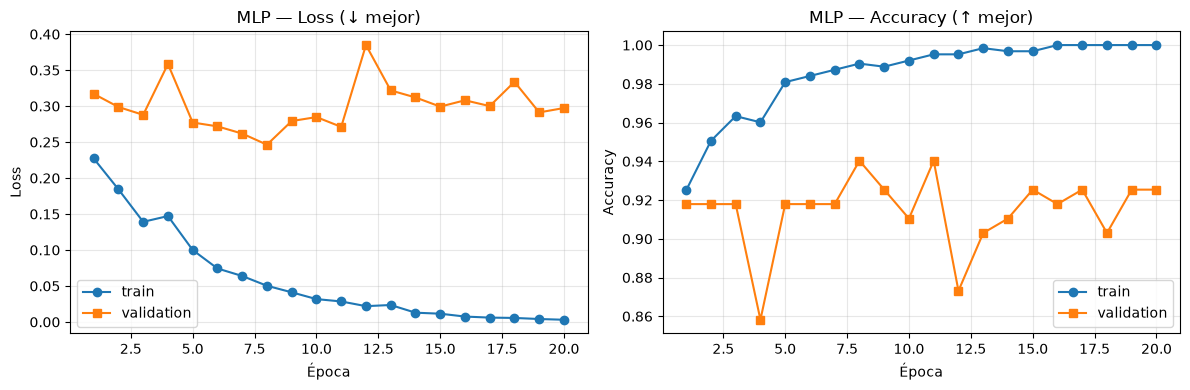

In [14]:
def graficar_historial(historial, titulo):
    """Curvas de loss y accuracy durante el entrenamiento."""
    epocas = range(1, len(historial["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epocas, historial["train_loss"], "o-", label="train")
    ax1.plot(epocas, historial["val_loss"], "s-", label="validation")
    ax1.set_xlabel("Época"); ax1.set_ylabel("Loss")
    ax1.set_title(f"{titulo} — Loss (↓ mejor)"); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epocas, historial["train_acc"], "o-", label="train")
    ax2.plot(epocas, historial["val_acc"], "s-", label="validation")
    ax2.set_xlabel("Época"); ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{titulo} — Accuracy (↑ mejor)"); ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


graficar_historial(historial_mlp, "MLP")


## Modelo 2: CNN LeNet-5

El MLP aplana la imagen y pierde la información espacial. Las **redes convolucionales (CNN)** resuelven esto:

- Una **convolución** desliza pequeños filtros (p. ej. de 5×5 píxeles) sobre la imagen, buscando patrones locales: bordes, esquinas, texturas. *No importa dónde esté la mano en la foto, el filtro la encuentra.*
- El **pooling** reduce el tamaño quedándose con lo más importante de cada zona (resumen).
- Al apilar capas, la red detecta patrones cada vez más complejos: bordes → dedos → mano completa.

Usaremos **LeNet-5** (Yann LeCun, 1998), la CNN que leía códigos postales en los 90 — ¡la abuela de las redes modernas! La adaptamos ligeramente: entrada a color (3 canales) de 32×32, y ReLU + MaxPool en lugar de las funciones originales.

```
3×32×32 → Conv(6 filtros 5×5) → Pool → Conv(16 filtros 5×5) → Pool → Flatten → 120 → 84 → 3
```


In [15]:
IMG_SIZE_CNN = 32

transform_cnn = transforms.Compose([
    transforms.Resize((IMG_SIZE_CNN, IMG_SIZE_CNN)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_dl_cnn, val_dl_cnn, test_dl_cnn, _ = crear_dataloaders(transform_cnn)


In [16]:
class LeNet5(nn.Module):
    """LeNet-5 (1998) adaptada: entrada RGB 32×32, ReLU y MaxPool."""

    def __init__(self, num_clases=3):
        super().__init__()
        self.extractor = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5),    # 3×32×32 → 6×28×28
            nn.ReLU(),
            nn.MaxPool2d(2),                   # → 6×14×14
            nn.Conv2d(6, 16, kernel_size=5),   # → 16×10×10
            nn.ReLU(),
            nn.MaxPool2d(2),                   # → 16×5×5
        )
        self.clasificador = nn.Sequential(
            nn.Flatten(),                      # 16×5×5 → 400
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, num_clases),
        )

    def forward(self, x):
        x = self.extractor(x)        # las convoluciones "ven" patrones
        return self.clasificador(x)  # las capas lineales deciden la clase


modelo_lenet = LeNet5().to(DEVICE)
print(modelo_lenet)
print(f"\nParámetros entrenables: {contar_parametros(modelo_lenet):,}")
print(f"(El MLP tenía {contar_parametros(modelo_mlp):,} — ¡la CNN es mucho más pequeña!)")


LeNet5(
  (extractor): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (clasificador): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): ReLU()
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): ReLU()
    (5): Linear(in_features=84, out_features=3, bias=True)
  )
)

Parámetros entrenables: 61,411
(El MLP tenía 1,639,427 — ¡la CNN es mucho más pequeña!)


Época 1/20 | train loss: 1.0840, acc: 41.79% | val loss: 1.0458, acc: 66.42%
Época 2/20 | train loss: 0.9579, acc: 73.05% | val loss: 0.7855, acc: 84.33%
Época 3/20 | train loss: 0.6239, acc: 84.21% | val loss: 0.4924, acc: 82.84%
Época 4/20 | train loss: 0.4138, acc: 86.44% | val loss: 0.3436, acc: 88.06%
Época 5/20 | train loss: 0.3183, acc: 88.84% | val loss: 0.3945, acc: 85.07%
Época 6/20 | train loss: 0.2420, acc: 92.98% | val loss: 0.2397, acc: 93.28%
Época 7/20 | train loss: 0.1945, acc: 93.46% | val loss: 0.2239, acc: 94.03%
Época 8/20 | train loss: 0.1492, acc: 96.01% | val loss: 0.1931, acc: 95.52%
Época 9/20 | train loss: 0.1298, acc: 96.49% | val loss: 0.2073, acc: 94.03%
Época 10/20 | train loss: 0.1252, acc: 95.69% | val loss: 0.1596, acc: 97.01%
Época 11/20 | train loss: 0.0905, acc: 96.81% | val loss: 0.1504, acc: 97.01%
Época 12/20 | train loss: 0.0866, acc: 96.97% | val loss: 0.1512, acc: 96.27%
Época 13/20 | train loss: 0.0705, acc: 97.45% | val loss: 0.1776, acc: 97

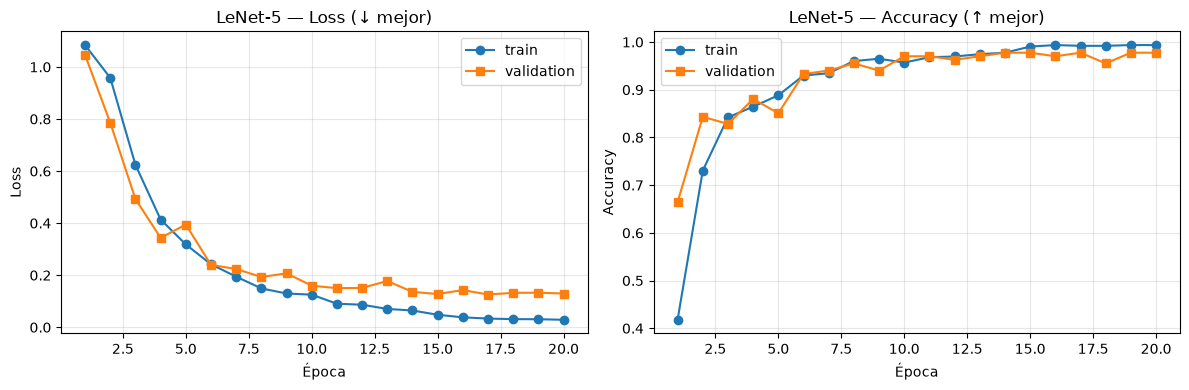

In [17]:
# Mismo pipeline de siempre: loss → optimizer → entrenar
optimizador_lenet = torch.optim.Adam(modelo_lenet.parameters(), lr=1e-3)

historial_lenet = fit(modelo_lenet, train_dl_cnn, val_dl_cnn, criterio, optimizador_lenet, EPOCAS)
graficar_historial(historial_lenet, "LeNet-5")


## Modelo 3: Transfer learning con ResNet-18

Hasta ahora nuestras redes aprenden a "ver" **desde cero** con ~2,000 imágenes. Pero existen redes ya entrenadas con **millones de imágenes** (ImageNet: 1.2M imágenes, 1000 categorías). Esas redes ya saben detectar bordes, texturas, formas, objetos...

**Transfer learning** = tomar una red pre-entrenada y adaptarla a *nuestro* problema:

1. Descargamos **ResNet-18** pre-entrenada (con la librería `timm`, un catálogo gigante de modelos).
2. **Congelamos** su cuerpo (sus pesos no se tocan — ya sabe "ver").
3. Reemplazamos su capa final por una de **3 salidas** y entrenamos **solo esa capa**.

> 👓 **Analogía:** no le enseñas a ver a un bebé; contratas a un experto con 20 años de experiencia visual y solo le explicas las reglas de piedra-papel-tijeras.

⚠️ Importante: usamos imágenes de **224×224** y la normalización de ImageNet, porque así fue entrenada ResNet.


In [ ]:
import timm

# Normalización con las estadísticas de ImageNet (así se entrenó ResNet)
transform_tl = transforms.Compose([
    transforms.Resize((224, 224)),## con esto fue entrenado y se tiene que convertir a ese tamaño
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_dl_tl, val_dl_tl, test_dl_tl, _ = crear_dataloaders(transform_tl, batch_size=32)


c:\Users\SAHUA\Documents\datascience-g8\01-python-intro\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Descargamos ResNet-18 pre-entrenada, con capa final nueva de 3 clases
modelo_tl = timm.create_model("resnet18", pretrained=True, num_classes=3)#### solo vamos a clasificar con el clasificador 

# 1) Congelar TODOS los pesos
for parametro in modelo_tl.parameters():
    parametro.requires_grad = False#### para no entrenar todas las capas

# 2) Descongelar solo la capa final (el "clasificador")
for parametro in modelo_tl.get_classifier().parameters():### solo usare el clasificador
    parametro.requires_grad = True

modelo_tl = modelo_tl.to(DEVICE)

total = sum(p.numel() for p in modelo_tl.parameters())
print(f"Parámetros totales:      {total:,}")
print(f"Parámetros entrenables:  {contar_parametros(modelo_tl):,} "
      f"({contar_parametros(modelo_tl) / total:.1%} del total)")


c:\Users\SAHUA\Documents\datascience-g8\01-python-intro\.venv\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\SAHUA\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Parámetros totales:      11,178,051
Parámetros entrenables:  1,539 (0.0% del total)


c:\Users\SAHUA\Documents\datascience-g8\01-python-intro\.venv\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\SAHUA\.cache\huggingface\hub\models--timm--resnet18.a1_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Época 1/10 | train loss: 0.6391, acc: 92.34% | val loss: 0.5508, acc: 96.27%
Época 2/10 | train loss: 0.5480, acc: 93.94% | val loss: 0.4748, acc: 96.27%
Época 3/10 | train loss: 0.4837, acc: 95.06% | val loss: 0.4198, acc: 96.27%
Época 4/10 | train loss: 0.4312, acc: 94.90% | val loss: 0.3731, acc: 97.01%
Época 5/10 | train loss: 0.4023, acc: 95.69% | val loss: 0.3433, acc: 96.27%
Época 6/10 | train loss: 0.3777, acc: 95.06% | val loss: 0.3088, acc: 97.01%
Época 7/10 | train loss: 0.3394, acc: 95.69% | val loss: 0.2845, acc: 96.27%
Época 8/10 | train loss: 0.3148, acc: 96.49% | val loss: 0.2614, acc: 97.01%
Época 9/10 | train loss: 0.2859, acc: 96.17% | val loss: 0.2441, acc: 97.01%
Época 10/10 | train loss: 0.2730, acc: 95.85% | val loss: 0.2352, acc: 97.76%


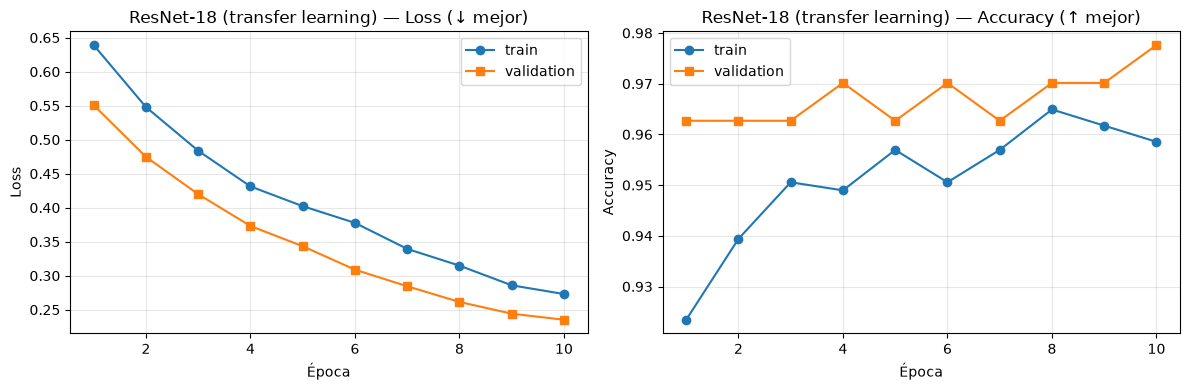

In [22]:
# Solo optimizamos los parámetros descongelados
optimizador_tl = torch.optim.Adam(
    (p for p in modelo_tl.parameters() if p.requires_grad), lr=1e-3
)

# Con transfer learning bastan pocas épocas
historial_tl = fit(modelo_tl, train_dl_tl, val_dl_tl, criterio, optimizador_tl, epocas=10)
graficar_historial(historial_tl, "ResNet-18 (transfer learning)")


### Bonus (opcional): fine-tuning completo

Si hay tiempo: en lugar de entrenar solo la última capa, podemos **descongelar toda la red** y ajustarla completa con un learning rate muy pequeño (`1e-5`), para no destruir lo que ya sabe. A esto se le llama **fine-tuning**.


In [ ]:
# Descongelamos todo y ajustamos con pasos muy pequeños
for parametro in modelo_tl.parameters():
    parametro.requires_grad = True

optimizador_ft = torch.optim.Adam(modelo_tl.parameters(), lr=1e-5)
historial_ft = fit(modelo_tl, train_dl_tl, val_dl_tl, criterio, optimizador_ft, epocas=2)


## Evaluación final: el examen con el test set

Momento de la verdad: evaluamos los 3 modelos con las imágenes de **test**, que ninguno vio durante el entrenamiento. Usaremos scikit-learn para:

- **Accuracy**: % de aciertos.
- **Matriz de confusión**: ¿*en qué* se equivoca cada modelo? (p. ej., ¿confunde piedra con tijeras?)
- **Classification report**: precisión y recall por clase.


In [ ]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)


@torch.no_grad()
def obtener_predicciones(modelo, dataloader):
    """Devuelve (etiquetas reales, etiquetas predichas) de todo un dataloader."""
    modelo.eval()
    y_real, y_pred = [], []
    for imagenes, etiquetas in dataloader:
        logits = modelo(imagenes.to(DEVICE))
        y_pred.extend(logits.argmax(dim=1).cpu().tolist())
        y_real.extend(etiquetas.tolist())
    return y_real, y_pred


modelos_finales = [
    ("MLP", modelo_mlp, test_dl_mlp),
    ("LeNet-5", modelo_lenet, test_dl_cnn),
    ("ResNet-18 (TL)", modelo_tl, test_dl_tl),
]

resultados = {}
predicciones = {}
for nombre, modelo, test_dl in modelos_finales:
    y_real, y_pred = obtener_predicciones(modelo, test_dl)
    predicciones[nombre] = (y_real, y_pred)
    resultados[nombre] = accuracy_score(y_real, y_pred)
    print(f"{nombre:>15s} → accuracy en test: {resultados[nombre]:.2%}")


In [ ]:
# Matriz de confusión: filas = clase real, columnas = clase predicha
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (nombre, (y_real, y_pred)) in zip(axes, predicciones.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_real, y_pred, display_labels=CLASES, ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(f"{nombre} ({resultados[nombre]:.1%})")
plt.tight_layout()
plt.show()


In [ ]:
# Reporte detallado del mejor modelo
mejor_nombre = max(resultados, key=resultados.get)
y_real, y_pred = predicciones[mejor_nombre]

print(f"📊 Classification report — {mejor_nombre}\n")
print(classification_report(y_real, y_pred, target_names=CLASES))


In [ ]:
# Comparación visual de los 3 modelos
fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.bar(resultados.keys(), resultados.values(),
                color=["#e74c3c", "#f39c12", "#27ae60"])
ax.bar_label(barras, fmt=lambda v: f"{v:.1%}", fontweight="bold")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy en test")
ax.set_title("¿Quién clasifica mejor piedra-papel-tijeras? 🪨📄✂️")
ax.grid(axis="y", alpha=0.3)
plt.show()


## Pruébalo tú: predice una imagen cualquiera

Cerramos el círculo: una función que recibe **una imagen** y devuelve la predicción con su nivel de confianza. Esto es exactamente lo que haría tu modelo en producción (en una app, una API, etc.).


In [ ]:
@torch.no_grad()
def predecir(ruta_imagen, modelo=modelo_tl, transform=transform_tl):
    """Clasifica una imagen y la muestra junto a la predicción."""
    modelo.eval()
    imagen = Image.open(ruta_imagen).convert("RGB")

    tensor = transform(imagen).unsqueeze(0).to(DEVICE)   # añadimos dimensión de batch
    probabilidades = torch.softmax(modelo(tensor), dim=1)[0]
    prediccion = probabilidades.argmax().item()

    plt.figure(figsize=(4, 3.5))
    plt.imshow(imagen)
    plt.axis("off")
    plt.title(f"Predicción: {CLASES[prediccion]} "
              f"({probabilidades[prediccion]:.1%} de confianza)")
    plt.show()

    for clase, prob in zip(CLASES, probabilidades):
        print(f"  {clase:>10s}: {prob:.1%}")


# Probemos con una imagen de cada clase
predecir(sorted((DATA_DIR / "rock").glob("*.png"))[100])
predecir(sorted((DATA_DIR / "paper").glob("*.png"))[100])
predecir(sorted((DATA_DIR / "scissors").glob("*.png"))[100])


## Guardar los modelos entrenados

Todo lo aprendido por una red vive en sus **pesos** (`state_dict`). Si no los guardamos, al cerrar el notebook el entrenamiento se pierde. La convención en PyTorch es guardar solo los pesos (no el objeto completo) en un archivo `.pt`.


In [ ]:
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

# Guardamos solo los pesos (state_dict), la práctica recomendada en PyTorch
torch.save(modelo_lenet.state_dict(), MODELS_DIR / "lenet5_rps.pt")
torch.save(modelo_tl.state_dict(), MODELS_DIR / "resnet18_rps.pt")

for archivo in sorted(MODELS_DIR.glob("*.pt")):
    tamano_mb = archivo.stat().st_size / 1024**2
    print(f"✅ {archivo.name} ({tamano_mb:.1f} MB)")


In [ ]:
# ¿Y cómo los recupero después? 1) crear la arquitectura, 2) cargar los pesos
lenet_cargada = LeNet5()
lenet_cargada.load_state_dict(
    torch.load(MODELS_DIR / "lenet5_rps.pt", map_location=DEVICE)
)
lenet_cargada.to(DEVICE).eval()

resnet_cargada = timm.create_model("resnet18", pretrained=False, num_classes=3)
resnet_cargada.load_state_dict(
    torch.load(MODELS_DIR / "resnet18_rps.pt", map_location=DEVICE)
)
resnet_cargada.to(DEVICE).eval()

# Comprobamos que el modelo cargado predice igual que el original
y_real, y_pred = obtener_predicciones(resnet_cargada, test_dl_tl)
from sklearn.metrics import accuracy_score
print(f"Accuracy de la ResNet-18 cargada desde disco: {accuracy_score(y_real, y_pred):.2%}")


## Cierre: ¿qué aprendimos?

| | MLP | LeNet-5 (CNN) | ResNet-18 (TL) |
|---|---|---|---|
| **Idea** | Aplana la imagen | Filtros que ven patrones locales | Reutiliza una red experta |
| **Entrada** | 64×64 | 32×32 | 224×224 |
| **Parámetros** | ~6.4M | ~63K | 11.2M (entrena ~0.01%) |
| **Conocimiento previo** | Ninguno | Ninguno | 1.2M imágenes de ImageNet |

**Las 3 lecciones clave:**

1. **El pipeline es siempre el mismo**: datos → preprocesamiento → dataloader → modelo → loss → optimizer → entrenar → evaluar. Cambia el modelo, el resto se reutiliza.
2. **Las CNN superan a los MLP en imágenes** porque respetan la estructura espacial (y con muchos menos parámetros).
3. **En la práctica casi nunca entrenas desde cero**: el transfer learning da mejores resultados, con menos datos y menos tiempo.

